# Qwen3.5-27B MLE-bench Evaluation Analysis

Model: Qwen/Qwen3.5-27B via vLLM (RolloutClient text mode)

Task: mlsp-2013-birds (64 samples)

In [51]:
import sys
sys.path.insert(0, "/home/winnieyangwn/rllm")
import importlib

import analysis.utils.eval_utils as eval_utils 

importlib.reload(eval_utils)
from analysis.utils.eval_utils import *

In [52]:
data_path = "/checkpoint/maui_sft/winnieyangwn/rllm/eval/qwen27b_vllm_test/results/trajectories.jsonl"

In [53]:
import pandas as pd

df = pd.read_json(data_path, lines=True)
print(f"Loaded {len(df)} trajectories")

/tmp/ipykernel_351489/2988924732.py:3: FutureWarning:

Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



ValueError: Expected object or value

Found 14 rollouts matching valid criteria
Found 1 rollouts matching invalid criteria (excluding infra errors)
Found 0 rollouts with infrastructure errors


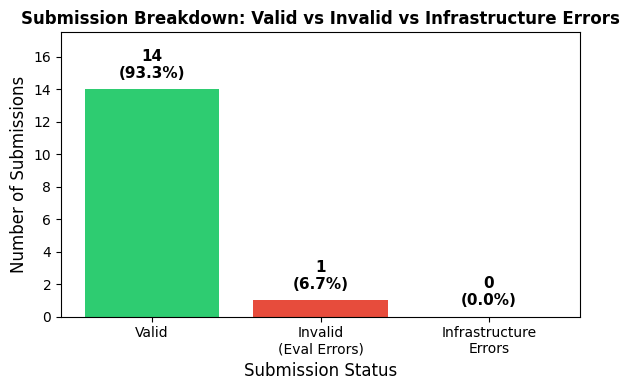

In [54]:
valid_df, invalid_df, infra_df = plot_submission_validity_breakdown(df)

Analyzing 15 rows for invalid submissions...
Found 1 invalid submissions

ERROR CATEGORY DISTRIBUTION


,Count,Percentage
Error Category,,
Context Length Exceeded,1,100.0



Total: 1

ROLLOUT INDICES BY ERROR CATEGORY


,Error Category,Count,Rollout Indices
0,Context Length Exceeded,1,[11]


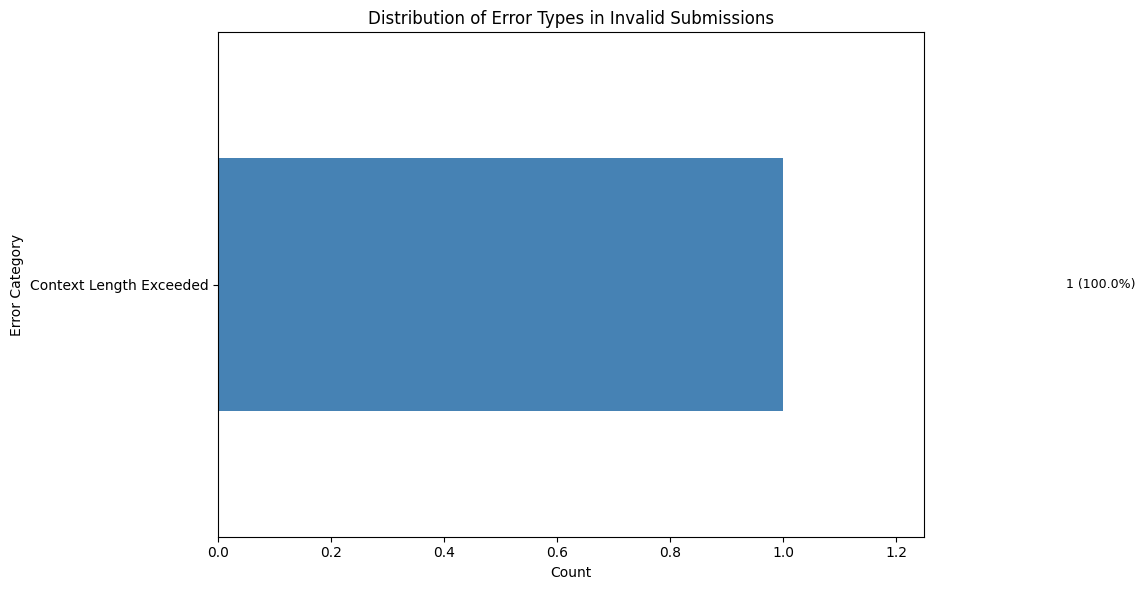


ERROR CATEGORY PERCENTAGE
Context Length Exceeded: 100.0%


In [46]:
# First analyze invalid submissions
df_errors, summary_df, rollout_indices_df = analyze_invalid_submissions(df)

# Then plot the distribution
error_counts, error_pct = plot_invalid_error_distribution(df_errors)

In [47]:
df.iloc[0]["outcomes"]

{'pass': True,
 'valid_submission': True,
 'pred_solution_provided': True,
 'submission_csv_provided': True,
 'max_turns_reached': False,
 'rollout_timeout': False,
 'context_exceeded': False,
 'model_call_error': False,
 'parse_error': False,
 'eval_timeout': False,
 'eval_outcome': 'pass',
 'eval_error_message': '',
 'eval_error_output': ''}

In [48]:
df_processed, df_task = process_df(df, Ks=[1, 4, 8, 16, 24, 32, 40, 48, 56, 64])

Using pre-computed pass@k for 1 tasks
Tasks: ['mlsp-2013-birds']


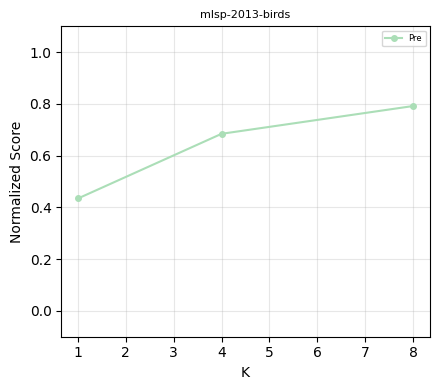

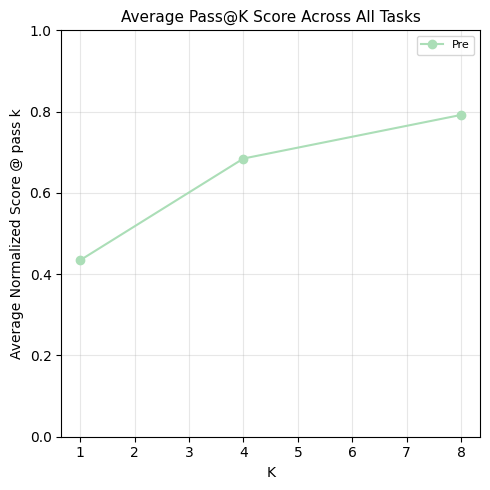

K	Pre
1	0.4346
4	0.6845
8	0.7918
16	nan
24	nan
32	nan
40	nan
48	nan
56	nan
64	nan


In [49]:
# Test pass@k for percentile scores
results_df = plot_pass_at_k(df_task, metric="percentile")

In [41]:
# Compare metrics across the full dataset
plot_metric_comparison([df_processed], labels=["Qwen3.5-27B"], metric="percentile", agg="mean")


plot_metric_comparison([df_processed], labels=["Qwen3.5-27B"], metric="medal", agg="mean")

Mean Percentile Qwen3.5-27B: 0.4130 ± 0.1733


Mean Any Medal Qwen3.5-27B: 0.0909 ± 0.3015
Mean Gold Medal Qwen3.5-27B: 0.0000 ± 0.0000
Mean Silver Medal Qwen3.5-27B: 0.0909 ± 0.3015
Mean Bronze Medal Qwen3.5-27B: 0.0000 ± 0.0000


({'any_medal': {'values': [np.float64(0.09090909090909091)],
   'stds': [np.float64(0.30151134457776363)]},
  'gold_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'silver_medal': {'values': [np.float64(0.09090909090909091)],
   'stds': [np.float64(0.30151134457776363)]},
  'bronze_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]}},
 None)

In [50]:
# Plot metric distribution - SEPARATE plot for each task
# Get all unique task names
task_names = df_processed['task_name'].unique().tolist()
print(f"Found {len(task_names)} tasks: {task_names}")

# This will create a separate 7-panel plot for EACH task
plot_metric_distribution(df_processed, task_name=task_names, labels=["All"])

Found 1 tasks: ['mlsp-2013-birds']



All - Task: mlsp-2013-birds
Valid submissions: 14 (93.3%)
Invalid submissions: 1 (6.7%)
Total submissions: 15

All rollout percentiles (invalid=0):
  Mean: 43.46%
  Median: 39.51%
  Max: 85.19%
  Min: 0.00%

Medal rates:
  Gold: 0.0%
  Silver: 6.7%
  Bronze: 13.3%
  Any Medal: 20.0%

Rollout duration (minutes):
  Mean: 35.5
  Median: 32.7
  Max: 55.4
  Min: 15.3

Total tokens:
  Mean: 81750
  Median: 67734
  Max: 250874
  Min: 54793


[{'task': 'mlsp-2013-birds',
  'results': [{'label': 'All',
    'valid_count': np.int64(14),
    'invalid_count': np.int64(1),
    'total_count': 15,
    'valid_rate': np.float64(93.33333333333333),
    'all_percentiles': [np.float64(0.28395061728395005),
     np.float64(0.5432098765432091),
     np.float64(0.308641975308641),
     np.float64(0.39506172839506104),
     np.float64(0.28395061728395005),
     np.float64(0.34567901234567905),
     np.float64(0.296296296296296),
     np.float64(0.518518518518518),
     np.float64(0.28395061728395005),
     np.float64(0.432098765432098),
     np.float64(0.8518518518518511),
     0.0,
     np.float64(0.7654320987654321),
     np.float64(0.45679012345679004),
     np.float64(0.7530864197530861)],
    'mean_percentile': np.float64(43.45679012345675),
    'medal_rates': {'gold_rate': np.float64(0.0),
     'silver_rate': np.float64(0.06666666666666667),
     'bronze_rate': np.float64(0.13333333333333333),
     'any_medal_rate': np.float64(0.2)},
